# Make article RD figures

Builds rate–distortion plots from your `runs/*/metrics.json` into `Article_SR/SR_article/figures/`.

**Current data:** 10-image sweeps are ready; full DIV2K / attnexp may still be incomplete.

| File | Source |
|------|--------|
| `fig03_rd_main.png` | Nina/Swin × direct/ADMM LoRA (`*_10`) |
| `fig04_lora_vs_full_rank.png` | Nina LoRA vs full_rank (`*_10`) |
| `fig05_lora_vs_attnexp.png` | Nina LoRA-all vs attnexp — run **after** attnexp finishes |

Static figures (`fig01`, `fig02`, `fig06`) are placed manually.

Run on Zhores. Safe to re-run: overwrites only the RD PNGs you regenerate.

In [9]:
from __future__ import annotations

import json
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# --- paths ---
PROJECT = Path("/gpfs/gpfs0/timofey.glukhikh/Science_Phan")
if not PROJECT.exists():
    PROJECT = Path("/gpfs/data/gpfs0/timofey.glukhikh/Science_Phan")
if not PROJECT.exists():
    # local checkout fallback
    PROJECT = Path("..").resolve()
    if not (PROJECT / "bitrate_sr").exists():
        PROJECT = Path("../..").resolve()

REPO = PROJECT
if not (REPO / "Article_SR" / "SR_article").exists():
    here = Path.cwd().resolve()
    for cand in [here, here.parent, here.parent.parent, PROJECT]:
        if (cand / "Article_SR" / "SR_article").exists():
            REPO = cand
            break
        if (cand / "SR_article").exists():
            REPO = cand.parent if cand.name == "Article_SR" else cand
            break

ARTICLE = REPO / "Article_SR" / "SR_article"
if not ARTICLE.exists():
    ARTICLE = REPO / "SR_article"
FIG_DIR = ARTICLE / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

RUNS = PROJECT / "runs"

print("PROJECT", PROJECT)
print("ARTICLE", ARTICLE)
print("FIG_DIR", FIG_DIR)
print("RUNS exists", RUNS.exists(), "->", RUNS)

PROJECT /gpfs/gpfs0/timofey.glukhikh/Science_Phan
ARTICLE /beegfs/home/timofey.glukhikh/SkoltechPhanSR/Article_SR/SR_article
FIG_DIR /beegfs/home/timofey.glukhikh/SkoltechPhanSR/Article_SR/SR_article/figures
RUNS exists True -> /gpfs/gpfs0/timofey.glukhikh/Science_Phan/runs


## 1. RD helpers (load mean curves from runs)

In [10]:
def glob_pat(backbone: str, method: str, adapt: str = "lora") -> str:
    if adapt == "full_rank":
        return f"img*_{backbone}_psnr35_lam*_{method}_full_rank"
    if adapt == "attnexp":
        return f"img*_{backbone}_psnr35_lam*_r4_{method}_attnexp"
    return f"img*_{backbone}_psnr35_lam*_r4_{method}"


def load_mean_rd(root: Path, backbone: str, method: str, adapt: str = "lora"):
    by_lam: dict[float, list[tuple[float, float]]] = defaultdict(list)
    if not root.exists():
        return [], [], [], []
    for d in root.glob(glob_pat(backbone, method, adapt)):
        mf = d / "metrics.json"
        if not mf.exists():
            continue
        m = json.loads(mf.read_text())
        lam, bpp, psnr = m.get("lambda"), m.get("Bpp"), m.get("PSNR_cmpref")
        if lam is None or bpp is None or psnr is None:
            continue
        by_lam[float(lam)].append((float(bpp), float(psnr)))
    lams = sorted(by_lam)
    xs, ys, ns = [], [], []
    for lam in lams:
        pts = by_lam[lam]
        xs.append(float(np.mean([p[0] for p in pts])))
        ys.append(float(np.mean([p[1] for p in pts])))
        ns.append(len(pts))
    return lams, xs, ys, ns


def plot_rd(series: dict, title: str, out_name: str, styles: dict | None = None):
    """series: key -> (root, backbone, method, adapt, label)"""
    fig, ax = plt.subplots(figsize=(7.2, 4.8))
    any_curve = False
    default_fmts = ["o-", "s--", "^-", "d--", "v-.", "P:", "X-", "*-."]
    for i, (key, (root, backbone, method, adapt, label)) in enumerate(series.items()):
        lams, bpp, psnr, ns = load_mean_rd(Path(root), backbone, method, adapt)
        n_dirs = len(list(Path(root).glob(glob_pat(backbone, method, adapt)))) if Path(root).exists() else 0
        print(f"{key:28s} exists={Path(root).exists()} dirs≈{n_dirs:4d} λ={len(lams)} n/λ={ns or '-'}")
        if not lams:
            continue
        any_curve = True
        if styles and key in styles:
            fmt, color = styles[key]
        else:
            fmt, color = default_fmts[i % len(default_fmts)], f"C{i}"
        order = np.argsort(bpp)
        xs = [bpp[j] for j in order]
        ys = [psnr[j] for j in order]
        ls = [lams[j] for j in order]
        ax.plot(xs, ys, fmt, color=color, markersize=7, label=f"{label} (n≈{max(ns)})")
        for x, y, lam in zip(xs, ys, ls):
            ax.annotate(f"λ={lam:g}", (x, y), textcoords="offset points", xytext=(3, 3), fontsize=7, color=color)
    ax.set_xlabel("Bpp (mean over images)")
    ax.set_ylabel("PSNR vs GT (compressed, mean)")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    if any_curve:
        ax.legend(fontsize=8)
    out = FIG_DIR / out_name
    fig.tight_layout()
    fig.savefig(out, dpi=200, bbox_inches="tight")
    print("Saved ->", out)
    plt.show()
    plt.close(fig)
    return any_curve

## 2. Main RD — `fig03_rd_main.png` (10 images, LoRA)

nina_direct                  exists=True dirs≈  80 λ=8 n/λ=[10, 10, 10, 10, 10, 10, 10, 10]
nina_admm                    exists=True dirs≈  80 λ=8 n/λ=[10, 10, 10, 10, 10, 10, 10, 10]
swin_direct                  exists=True dirs≈  80 λ=8 n/λ=[10, 10, 10, 10, 10, 10, 10, 10]
swin_admm                    exists=True dirs≈  80 λ=8 n/λ=[10, 10, 10, 10, 10, 10, 10, 10]
Saved -> /beegfs/home/timofey.glukhikh/SkoltechPhanSR/Article_SR/SR_article/figures/fig03_rd_main.png


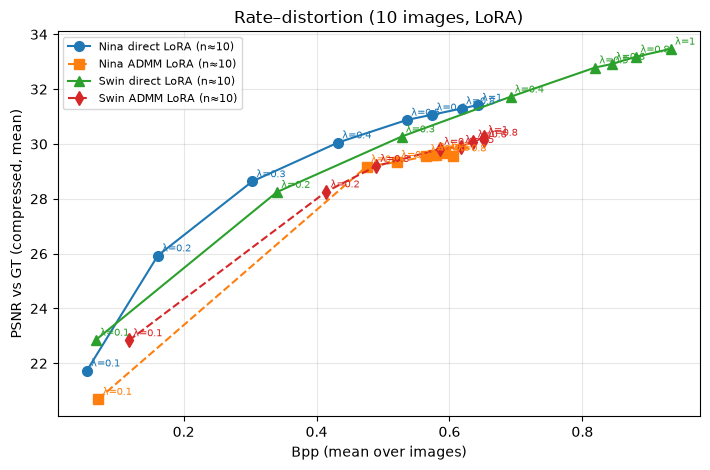

True

In [11]:
plot_rd(
    {
        "nina_direct": (RUNS / "bitrate_sr_nina_direct_10", "nina", "direct", "lora", "Nina direct LoRA"),
        "nina_admm": (RUNS / "bitrate_sr_nina_admm_10", "nina", "admm", "lora", "Nina ADMM LoRA"),
        "swin_direct": (RUNS / "bitrate_sr_swin_direct_10", "swin", "direct", "lora", "Swin direct LoRA"),
        "swin_admm": (RUNS / "bitrate_sr_swin_admm_10", "swin", "admm", "lora", "Swin ADMM LoRA"),
    },
    title="Rate–distortion (10 images, LoRA)",
    out_name="fig03_rd_main.png",
)

## 3. LoRA vs full_rank — `fig04_lora_vs_full_rank.png` (10 images)

nina_d_lora                  exists=True dirs≈  80 λ=8 n/λ=[10, 10, 10, 10, 10, 10, 10, 10]
nina_d_fr                    exists=True dirs≈  80 λ=8 n/λ=[10, 10, 10, 10, 10, 10, 10, 10]
nina_a_lora                  exists=True dirs≈  80 λ=8 n/λ=[10, 10, 10, 10, 10, 10, 10, 10]
nina_a_fr                    exists=True dirs≈  80 λ=8 n/λ=[10, 10, 10, 10, 10, 10, 10, 10]
Saved -> /beegfs/home/timofey.glukhikh/SkoltechPhanSR/Article_SR/SR_article/figures/fig04_lora_vs_full_rank.png


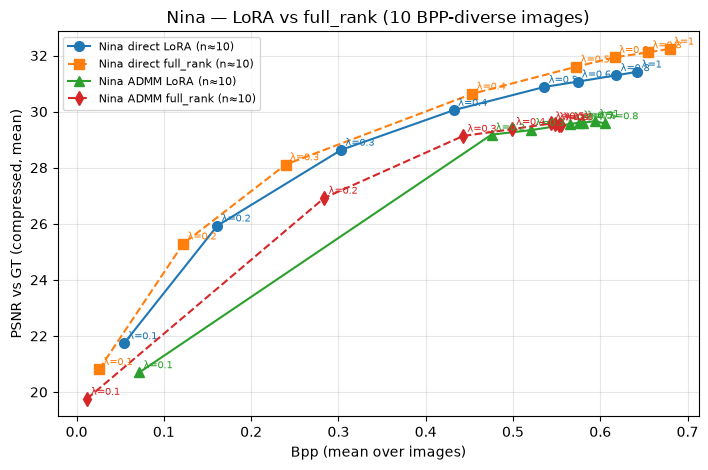

True

In [12]:
plot_rd(
    {
        "nina_d_lora": (RUNS / "bitrate_sr_nina_direct_10", "nina", "direct", "lora", "Nina direct LoRA"),
        "nina_d_fr": (RUNS / "bitrate_sr_nina_direct_full_rank_10", "nina", "direct", "full_rank", "Nina direct full_rank"),
        "nina_a_lora": (RUNS / "bitrate_sr_nina_admm_10", "nina", "admm", "lora", "Nina ADMM LoRA"),
        "nina_a_fr": (RUNS / "bitrate_sr_nina_admm_full_rank_10", "nina", "admm", "full_rank", "Nina ADMM full_rank"),
    },
    title="Nina — LoRA vs full_rank (10 BPP-diverse images)",
    out_name="fig04_lora_vs_full_rank.png",
)

## 4. LoRA all vs attnexp — `fig05_lora_vs_attnexp.png` (Nina, 10 images)

Skip until `bitrate_sr_nina_*_attnexp_10` finishes. Set `RUN_ATTNEXP = True` below when ready.

In [13]:
RUN_ATTNEXP = False  # flip to True after attnexp jobs complete

if RUN_ATTNEXP:
    plot_rd(
        {
            "d_all": (RUNS / "bitrate_sr_nina_direct_10", "nina", "direct", "lora", "direct LoRA-all"),
            "d_ae": (RUNS / "bitrate_sr_nina_direct_attnexp_10", "nina", "direct", "attnexp", "direct attnexp"),
            "a_all": (RUNS / "bitrate_sr_nina_admm_10", "nina", "admm", "lora", "ADMM LoRA-all"),
            "a_ae": (RUNS / "bitrate_sr_nina_admm_attnexp_10", "nina", "admm", "attnexp", "ADMM attnexp"),
        },
        title="Nina — LoRA all vs attention_expand (10 images)",
        out_name="fig05_lora_vs_attnexp.png",
    )
else:
    print("Skipped fig05 (RUN_ATTNEXP=False). Re-run this cell when attnexp is done.")

Skipped fig05 (RUN_ATTNEXP=False). Re-run this cell when attnexp is done.


## 5. Summary

In [14]:
want = [
    ("fig03_rd_main.png", True),
    ("fig04_lora_vs_full_rank.png", True),
    ("fig05_lora_vs_attnexp.png", False),  # expected later
]
print("RD figures in", FIG_DIR)
for name, required in want:
    p = FIG_DIR / name
    if p.is_file():
        print(f"  OK       {p.name:40s}  {p.stat().st_size/1024:.1f} KiB")
    elif required:
        print(f"  MISSING  {name}")
    else:
        print(f"  pending  {name}  (attnexp)")

RD figures in /beegfs/home/timofey.glukhikh/SkoltechPhanSR/Article_SR/SR_article/figures
  OK       fig03_rd_main.png                         152.7 KiB
  OK       fig04_lora_vs_full_rank.png               167.0 KiB
  pending  fig05_lora_vs_attnexp.png  (attnexp)
